In [1]:
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from sqlalchemy import create_engine
import urllib.parse
from dotenv import load_dotenv
from statsmodels.graphics.tsaplots import plot_pacf
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score
import shap
import joblib

load_dotenv()

True

In [2]:
# create a connection to my Database
engine = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{urllib.parse.quote_plus(os.getenv('DB_PASS'))}@"
    f"{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

# Load
df = pd.read_sql("SELECT * FROM daily_weather WHERE city = 'Abuja' ORDER BY date",
                 engine, index_col='date', parse_dates=['date'])

print("After load:", df.shape)

After load: (2292, 33)


In [3]:
# broad overview of my features
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2292 entries, 2020-01-01 to 2026-04-10
Data columns (total 33 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   city            2292 non-null   object 
 1   temp_avg        2292 non-null   float64
 2   temp_max        2292 non-null   float64
 3   temp_min        2292 non-null   float64
 4   feelslike       2292 non-null   float64
 5   feelslikemax    2292 non-null   float64
 6   feelslikemin    2292 non-null   float64
 7   dew             2292 non-null   float64
 8   humidity        2292 non-null   float64
 9   precip          2292 non-null   float64
 10  precipprob      2292 non-null   float64
 11  precipcover     2292 non-null   float64
 12  preciptype      1254 non-null   object 
 13  snow            2292 non-null   float64
 14  snowdepth       2292 non-null   float64
 15  windgust        2292 non-null   float64
 16  windspeed       2292 non-null   float64
 17  winddir        

In [4]:
# check percantage of empty cells
# Calculate percentage of empty cells
null_pct = (df.isnull().sum() / len(df)) * 100

# Filter out columns with 0% empty cells and sort in ascendng order
null_pct = null_pct[null_pct > 0].sort_values(ascending=False)

print("Percentage of missing values per column:")
print(null_pct)

Percentage of missing values per column:
preciptype    45.287958
severerisk    34.947644
stations       0.610820
visibility     0.305410
dtype: float64


In [5]:
# For now, i will use forward fill to fix the nulls for features less than 10%
df['pressure'] = df['pressure'].ffill()
df['visibility'] = df['visibility'].ffill()

#check to confirm
print(df[['pressure', 'visibility']].isnull().sum())

pressure      0
visibility    0
dtype: int64


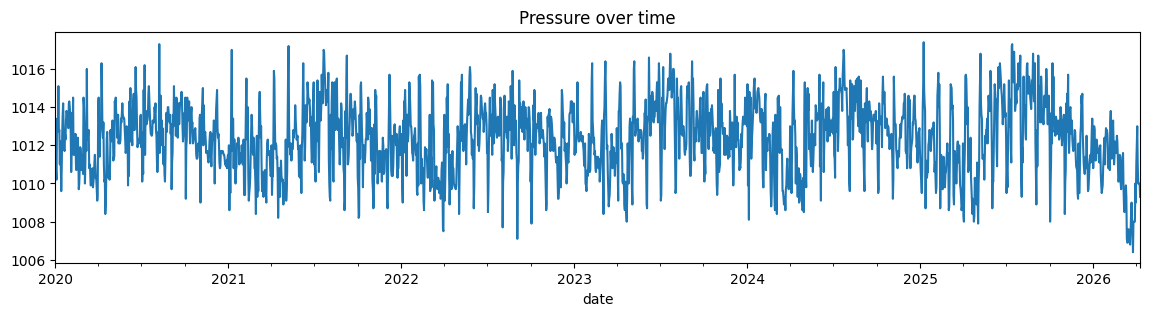

In [6]:
# Plot Pressure over time to check if the forward filling created any flatline.
df['pressure'].plot(figsize=(14, 3), title='Pressure over time')
plt.show()

In [7]:
# check if i have less than 0 in my precip column so i can clean them because precip cannot be less than 0.
print("Negative precip values:", (df['precip'] < 0).sum())
print("Min precip value:", df['precip'].min())

Negative precip values: 0
Min precip value: 0.0


In [8]:
# i create the target column where precip greater than 0 is identified as rain and 0 is no rain.
# rain is my positive class while no_rain is my negative class.
df["is_rain"]= (df['precip'] > 0.0).astype(int)

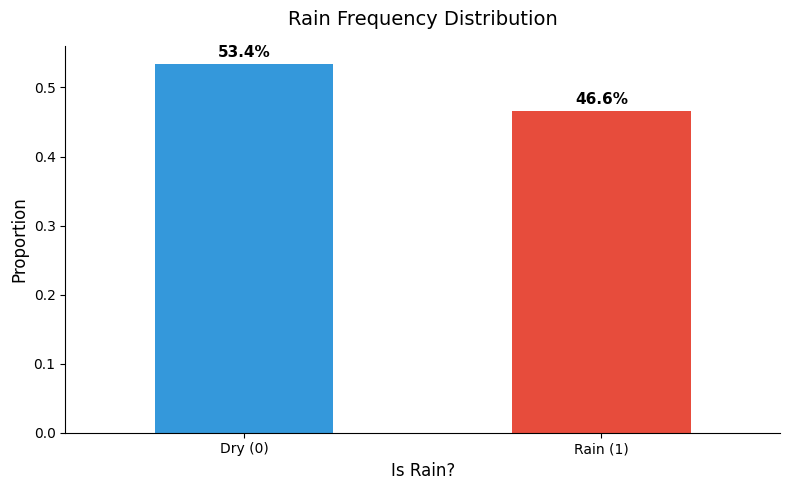

In [9]:
# 1. Calculate the proportions to see if i have an imbalanced dataset
counts = df["is_rain"].value_counts(normalize=True)

# 2. Plot with colors and no rotation on labels
ax = counts.plot(kind="bar", color=["#3498db", "#e74c3c"], rot=0, figsize=(8, 5))

# 3. Add Title and better Axis labels
plt.title("Rain Frequency Distribution", fontsize=14, pad=15)
plt.ylabel("Proportion", fontsize=12)
plt.xlabel("Is Rain?", fontsize=12)
plt.xticks([0, 1], ["Dry (0)", "Rain (1)"])

# 4. Add data labels on top of the bars
for i, v in enumerate(counts):
    ax.text(i, v + 0.01, f"{v:.1%}", ha='center', fontweight='bold', fontsize=11)

# 5. Clean up the "box"
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("./images/rain_frequency.png")
plt.show()

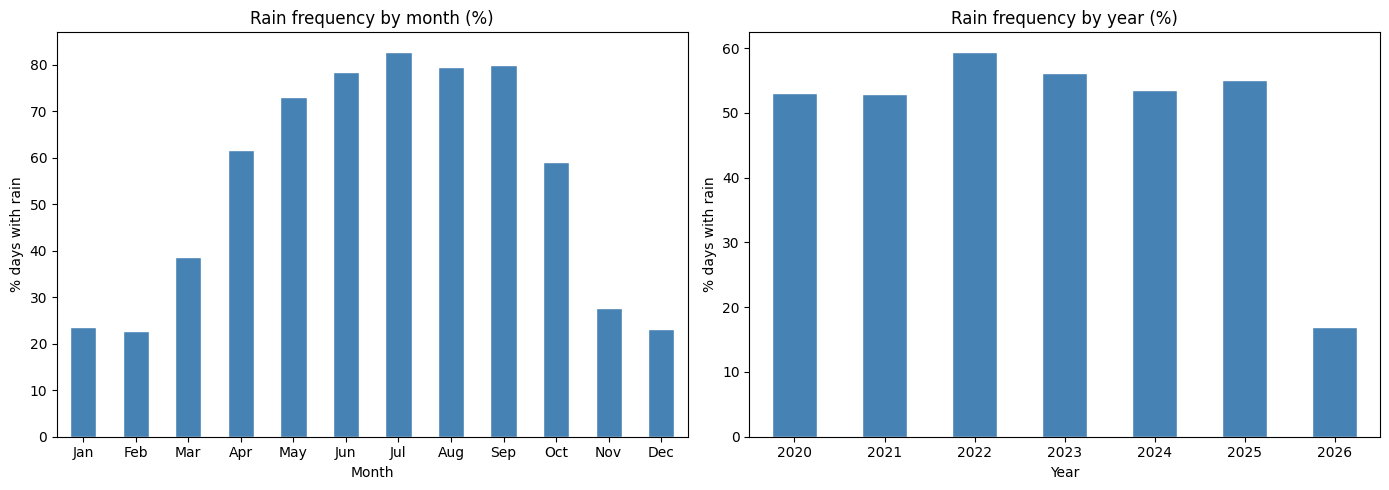

In [10]:
# check out rain distrubution by Month and by Year to see if i have any abnormalities.
df['is_rain'] = (df['precip'] > 0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rain frequency by month
df.groupby(df.index.month)['is_rain'].mean().mul(100).plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Rain frequency by month (%)')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('% days with rain')
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'], rotation=0)

# Rain frequency by year
df.groupby(df.index.year)['is_rain'].mean().mul(100).plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='white'
)
axes[1].set_title('Rain frequency by year (%)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('% days with rain')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

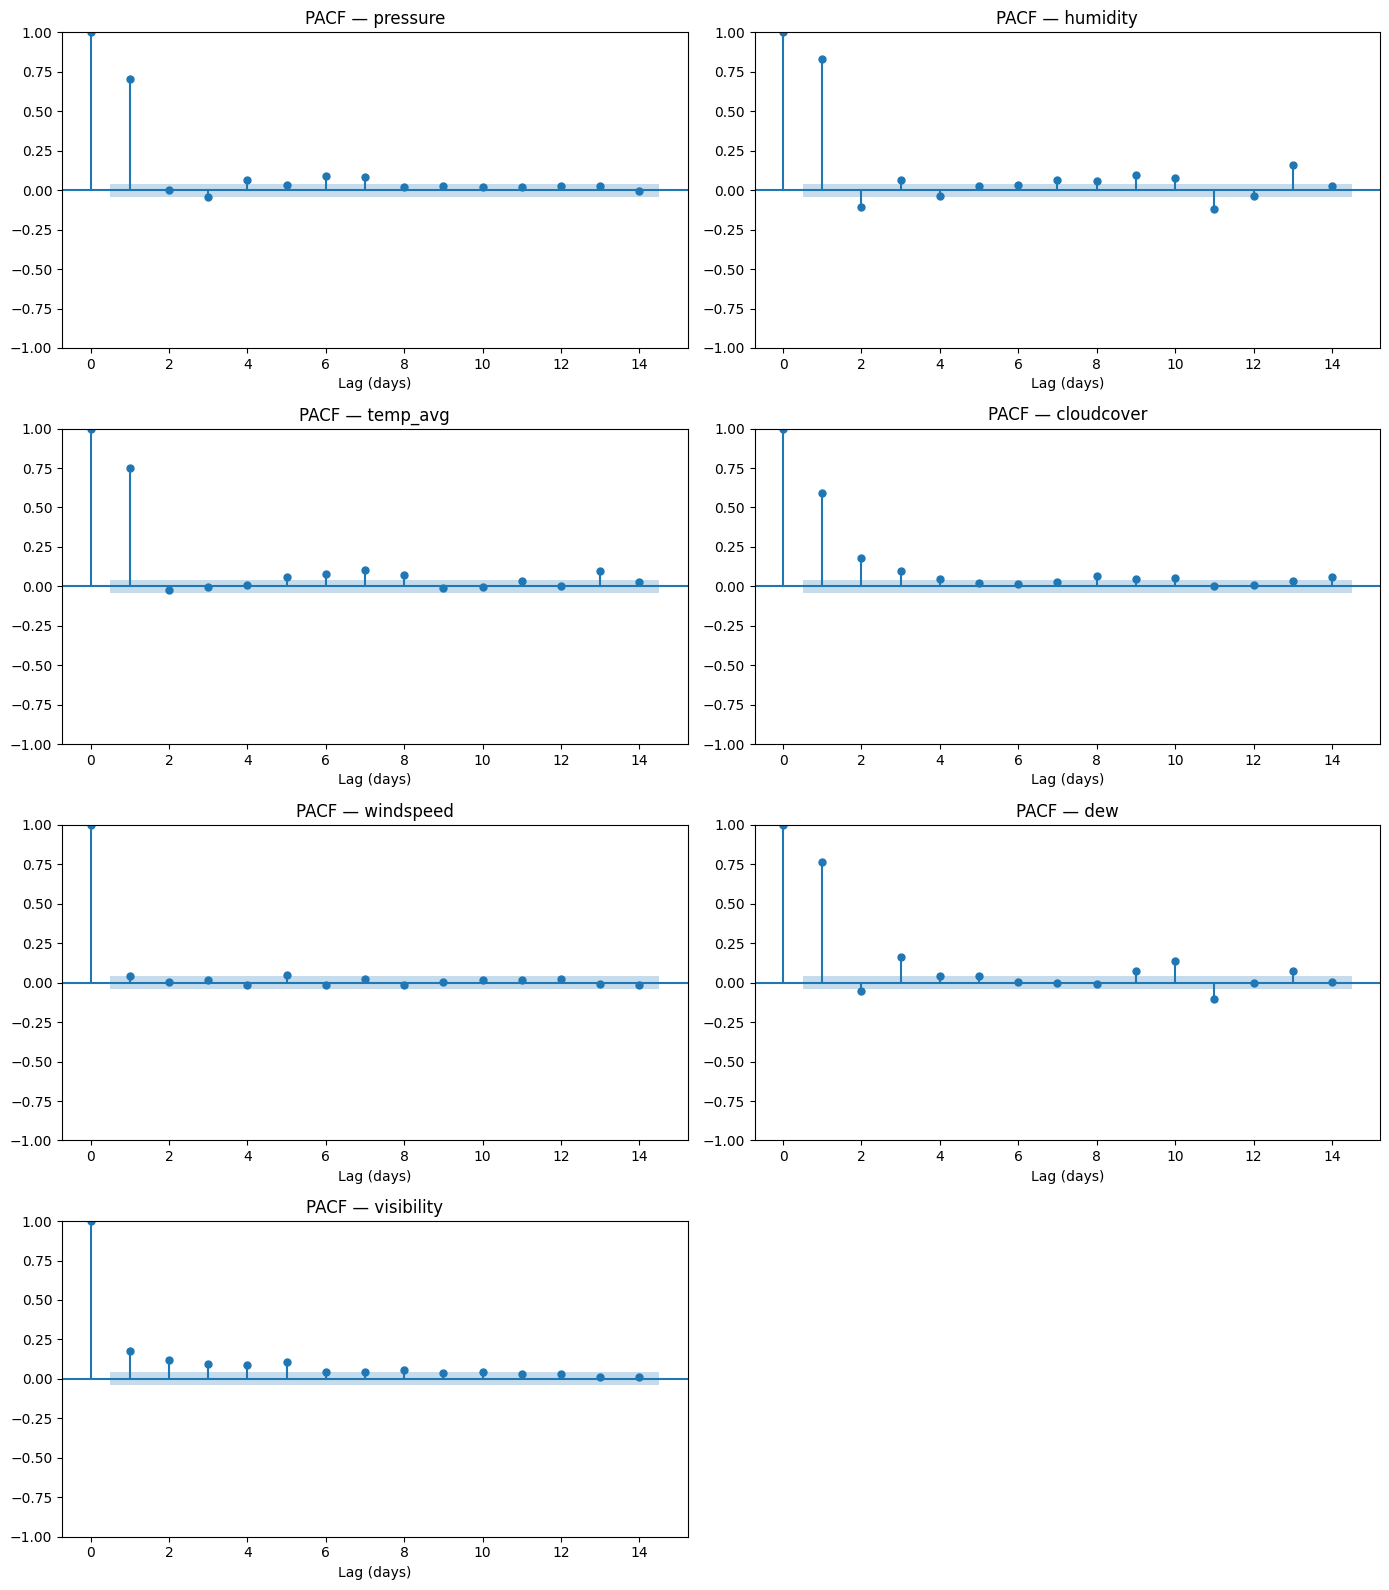

In [11]:
# bring out my suspected main features, and check the pacf on each of them,
# so i can know which lags to use for them.
features = ['pressure', 'humidity', 'temp_avg', 'cloudcover', 
                      'windspeed', 'dew', 'visibility']

fig, axes = plt.subplots(4, 2, figsize=(14, 16))

for ax, col in zip(axes.flatten(), features):
    plot_pacf(df[col].dropna(), lags=14, ax=ax, method='ywm')
    ax.set_title(f'PACF — {col}')
    ax.set_xlabel('Lag (days)')

axes[-1, -1].set_visible(False)  # hide the empty 8th subplot
plt.tight_layout()
plt.savefig("./images/pacf_plots.png")
plt.show()

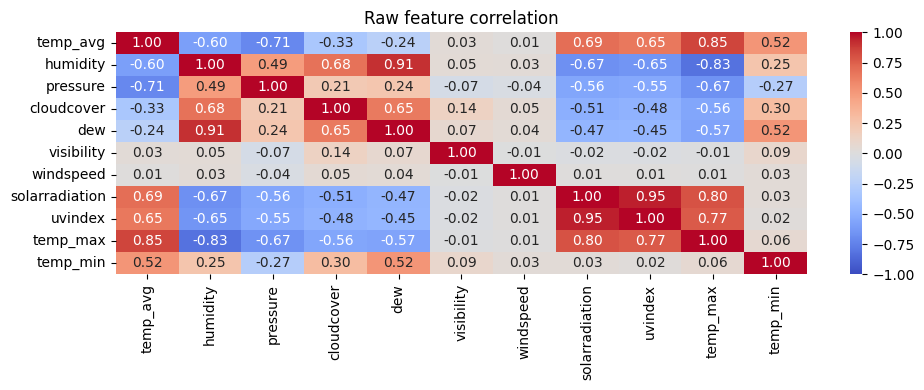

In [12]:
# check the correlation between my numerical features. so i can identify multicolinary features and deal with them.
features_to_check = [
    'temp_avg', 'humidity', 'pressure', 'cloudcover',
    'dew', 'visibility', 'windspeed',
    'solarradiation', 'uvindex', 'temp_max', 'temp_min'
]

corr = df[features_to_check].corr()

plt.figure(figsize=(10, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1)
plt.title('Raw feature correlation')
plt.tight_layout()
plt.savefig("./images/correlation_heatmap.png")
plt.show()

In [13]:
#features to drop and why
to_drop = [
    # Leaky
    'precip', 'precipprob', 'precipcover', 'preciptype',
    'conditions', 'description', 'icon', 'severerisk',
    'snow', 'snowdepth',
    # Redundant
    'feelslike', 'feelslikemax', 'feelslikemin',
    'dew', 'uvindex', 'temp_max', 'temp_min', 'solarenergy',
    # Metadata
    'city', 'source', 'stations', 'sunrise', 'sunset',
    # Also windgust — spiky, no memory, we never planned to keep it
    'windgust'
]

df = df.drop(columns=[c for c in to_drop if c in df.columns])

print(df.columns.tolist())
print("Shape:", df.shape)

['temp_avg', 'humidity', 'windspeed', 'winddir', 'pressure', 'cloudcover', 'visibility', 'solarradiation', 'moonphase', 'is_rain']
Shape: (2292, 10)


In [14]:
# create the lags, gotten from the Pacf plots drawn earlier
lag_config = {
    'pressure':   [1],
    'humidity':   [1, 2],
    'temp_avg':   [1],
    'cloudcover': [1, 2],
    'visibility': [1, 2, 3],
}
for col, lags in lag_config.items():
    for lag in lags:
        df[f'{col}_lag{lag}'] = df[col].shift(lag)

In [15]:
# calculate the deltas, this gives the model some sort of trend as to how
# that feature is progressing
for col in ['humidity', 'cloudcover', 'visibility']:
    df[f'{col}_delta'] = df[f'{col}_lag1'] - df[f'{col}_lag2']
df['pressure_delta'] = df['pressure'] - df['pressure_lag1']
df['temp_avg_delta'] = df['temp_avg'] - df['temp_avg_lag1']

In [16]:
# Cyclical, this makes sure that feature elements that are mumerically far
# but "physically" close, are brought together so the model can understand.
df['month_sin'] = np.sin(2 * np.pi * df.index.month / 12)
df['month_cos'] = np.cos(2 * np.pi * df.index.month / 12)
df['winddir_sin'] = np.sin(2 * np.pi * df['winddir'] / 360)
df['winddir_cos'] = np.cos(2 * np.pi * df['winddir'] / 360)
df = df.drop(columns=['winddir'])

In [17]:
# Rolling means, this gives the model some sort of backgroud state.
for col in ['pressure', 'humidity']:
    df[f'{col}_roll3'] = df[col].shift(1).rolling(3).mean()
    df[f'{col}_roll7'] = df[col].shift(1).rolling(7).mean()

In [18]:
# Drop Today's raw features
t0_to_drop = ['temp_avg', 'humidity', 'pressure', 'cloudcover',
               'visibility', 'windspeed', 'solarradiation', 'moonphase']
df = df.drop(columns=[c for c in t0_to_drop if c in df.columns])

In [19]:
# Drop NaN rows from lag creation and see a high level view of our dataset
df = df.dropna()

print("Shape:", df.shape)
print("Class balance:")
print(df['is_rain'].value_counts())
print("\nAny nulls?", df.isnull().sum().sum())

Shape: (2285, 23)
Class balance:
is_rain
1    1219
0    1066
Name: count, dtype: int64

Any nulls? 0


In [20]:
# Seperate our training set from test set sequentially

train = df[df.index.year <= 2024]
test  = df[df.index.year >= 2025]

X_train = train.drop(columns=['is_rain'])
y_train = train['is_rain']

X_test  = test.drop(columns=['is_rain'])
y_test  = test['is_rain']

print("Train:", X_train.shape, "- Rain:", y_train.sum(), "- No rain:", (y_train==0).sum())
print("Test: ", X_test.shape,  "- Rain:", y_test.sum(),  "- No rain:", (y_test==0).sum())

Train: (1820, 22) - Rain: 1001 - No rain: 819
Test:  (465, 22) - Rain: 218 - No rain: 247


In [21]:
# Time-series based cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Parameter grid
param_grid = {
    'n_estimators':  [100, 200, 300],
    'max_depth':     [3, 4, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample':     [0.7, 0.9, 1.0],
}

# search our grid based on the hyperparameters in param_grid
model_tuned = GridSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid=param_grid,
    cv=tscv,
    scoring='f1',       # optimise for Rain F1
    n_jobs=-1,          # use all CPU cores
    verbose=1
)

# train the model
model_tuned.fit(X_train, y_train)

print("Best params:", model_tuned.best_params_)
print("Best CV F1: ", round(model_tuned.best_score_, 4))

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best params: {'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.7}
Best CV F1:  0.8655


In [22]:
# more information on te different hyperparameters gotten.
results =pd.DataFrame(model_tuned.cv_results_)
results.sort_values("rank_test_score").head(3)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_max_depth,param_n_estimators,param_subsample,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
24,0.782167,0.244181,0.010653,0.003220,0.01,6,300,0.7,"{'learning_rate': 0.01, 'max_depth': 6, 'n_est...",0.867797,0.785047,0.882540,0.908571,0.883469,0.865485,0.042300,1
40,0.255780,0.048417,0.007691,0.000566,0.05,4,200,0.9,"{'learning_rate': 0.05, 'max_depth': 4, 'n_est...",0.855219,0.798722,0.876190,0.910663,0.881720,0.864503,0.037355,2
28,0.101879,0.012878,0.006657,0.000205,0.05,3,100,0.9,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",0.860068,0.797508,0.872274,0.907042,0.881720,0.863723,0.036528,3


              precision    recall  f1-score   support

     No Rain       0.89      0.85      0.87       247
        Rain       0.83      0.88      0.86       218

    accuracy                           0.86       465
   macro avg       0.86      0.86      0.86       465
weighted avg       0.86      0.86      0.86       465



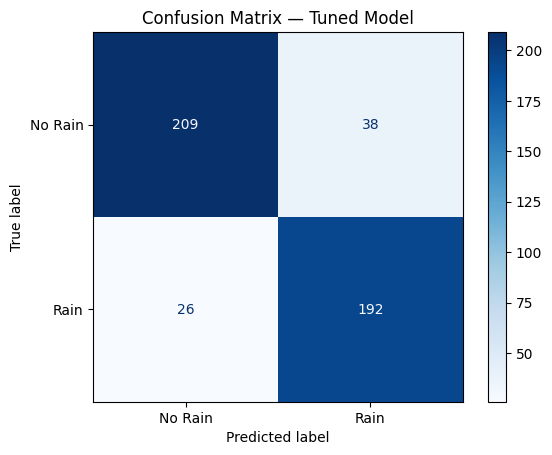

In [23]:
# check out our model on the test set and then evaluate with confusion matrix
y_pred = model_tuned.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['No Rain', 'Rain']))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Rain', 'Rain']).plot(cmap='Blues')
plt.title('Confusion Matrix — Tuned Model')

plt.savefig("./images/confusion_matrix.png")
plt.show()

2022 → F1 Rain: 0.848 | F1 No Rain: 0.807
2023 → F1 Rain: 0.875 | F1 No Rain: 0.819
2024 → F1 Rain: 0.883 | F1 No Rain: 0.857
2025 → F1 Rain: 0.890 | F1 No Rain: 0.860


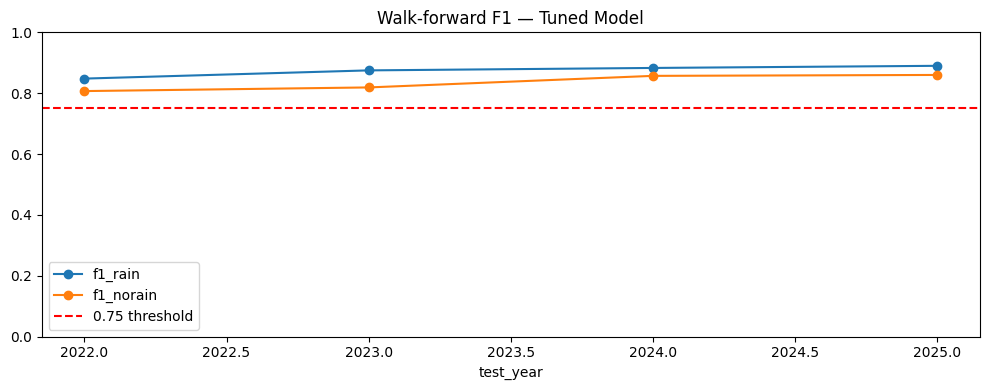

In [24]:
# Create an empty list to store my F1 scores across the different years.
results_tuned = []

# Loop through the years in the test set
for test_year in [2022, 2023, 2024, 2025]:
    
    # use an expanding window split
    # Train on all history up to this year, then test ONLY on this specific year.
    # As the loop moves forward, our 'train_wf' set naturally gets bigger.
    train_wf = df[df.index.year < test_year]
    test_wf  = df[df.index.year == test_year]

    # Separate features (X) from target (y)
    X_tr = train_wf.drop(columns=['is_rain'])
    y_tr = train_wf['is_rain']
    X_te = test_wf.drop(columns=['is_rain'])
    y_te = test_wf['is_rain']

    # Create a fresh XGBoost model. The '**' magic unpacks all the absolute 
    # best settings we found earlier and plugs them straight into this new model.
    m = XGBClassifier(**model_tuned.best_params_, random_state=42, eval_metric='logloss')
    
    # Study the historical data, then take the test for the current year
    m.fit(X_tr, y_tr)
    y_pred = m.predict(X_te)


    # Calculate the F1 score for finding Rain (1) and No Rain (0)
    f1_rain   = f1_score(y_te, y_pred, pos_label=1)
    f1_norain = f1_score(y_te, y_pred, pos_label=0)

    # Write the final scores down in result_tuned list 
    # when the loop moves to the next year
    results_tuned.append({
        'test_year': test_year,
        'f1_rain':   round(f1_rain, 3),
        'f1_norain': round(f1_norain, 3),
    })
    
    # Print a quick status update to the screen
    print(f"{test_year} → F1 Rain: {f1_rain:.3f} | F1 No Rain: {f1_norain:.3f}")


# Use the data stored in the results_tuned,to create a line graph after making a dataframe
pd.DataFrame(results_tuned).plot(
    x='test_year', y=['f1_rain', 'f1_norain'],
    marker='o', figsize=(10, 4),
    title='Walk-forward F1 — Tuned Model'
)

# Draw a red dashed line at 0.75 as a visual "minimum passing grade" benchmark
plt.axhline(y=0.75, color='red', linestyle='--', label='0.75 threshold')

# Lock the Y-axis from 0 to 1 (since F1 scores are percentages)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

plt.savefig("./images/walkforward_tuned.png")
# Show the final chart
plt.show()

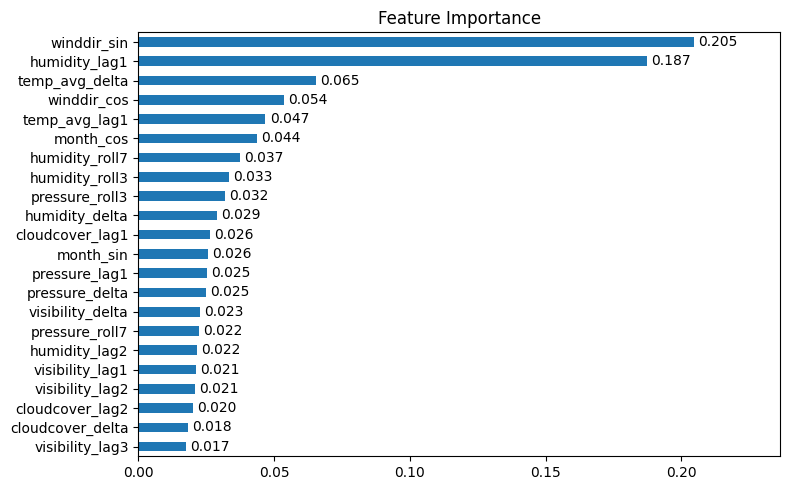

In [25]:
# Feature Importance to see how relevent each feature is to our model.
# 1. Save the plot to a variable called 'ax'
ax = pd.Series(
    model_tuned.best_estimator_.feature_importances_,
    index=X_train.columns
).sort_values().plot(kind='barh', figsize=(8, 5), title='Feature Importance')

# 2. Loop through the bars and add labels to the end of them
for container in ax.containers:
    # fmt='%.3f' rounds the label to 3 decimal places so it isn't too long
    # padding=3 adds a bit of space between the bar and the text
    ax.bar_label(container, fmt='%.3f', padding=3)

# Give the labels a little extra breathing room on the right side
# so they don't get cut off by the edge of the picture
ax.set_xlim(right=ax.get_xlim()[1] * 1.1)

plt.tight_layout()
plt.savefig("./images/feature_importance.png")
plt.show()

In [26]:
df.head(3)

,is_rain,pressure_lag1,humidity_lag1,humidity_lag2,temp_avg_lag1,cloudcover_lag1,cloudcover_lag2,visibility_lag1,visibility_lag2,visibility_lag3,...,pressure_delta,temp_avg_delta,month_sin,month_cos,winddir_sin,winddir_cos,pressure_roll3,pressure_roll7,humidity_roll3,humidity_roll7
date,,,,,,,,,,,,,,,,,,,,,
2020-01-08,1,1013.3,83.7,82.5,26.0,60.9,83.8,6.2,6.2,6.4,...,1.8,-1.4,0.5,0.866025,-0.901833,-0.432086,1013.266667,1012.300000,77.033333,57.928571
2020-01-09,1,1015.1,86.7,83.7,24.6,78.9,60.9,6.2,6.2,6.2,...,-2.4,-1.4,0.5,0.866025,-0.973976,-0.226651,1013.933333,1012.742857,84.300000,65.557143
2020-01-10,1,1012.7,89.0,86.7,23.2,72.3,78.9,5.9,6.2,6.2,...,0.1,1.8,0.5,0.866025,-0.990983,0.133986,1013.700000,1012.642857,86.466667,74.271429


In [27]:
#joblib.dump(model_tuned, './mlruns/rain_model_v3.pkl')
#print("Model saved.")